# Decision tree classification with training-only model selection

Use the UCI processed Cleveland data to compare a pruned tree against majority and logistic regression baselines. This is an educational benchmark, not a diagnostic tool. Dataset attribution: [DATA_SOURCES.md](../DATA_SOURCES.md).


In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'ml_fundamentals').exists():
    root = root.parent
if not (root / 'ml_fundamentals').exists():
    raise RuntimeError('Start Jupyter from the repository root')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt

from ml_fundamentals.heart import load_data,evaluate_heart
import pandas as pd
data=root/'Decision_trees'/'processed.cleveland.data'
X,y=load_data(data)
print('Rows:',len(X),'Missing cells:',int(X.isna().sum().sum()))
print('Class counts:',y.value_counts().sort_index().to_dict())


Rows: 303 Missing cells: 6
Class counts: {0: 164, 1: 139}


Protocol fixed before evaluation: stratified 75/25 split with seed 42; five shuffled stratified training folds; choose pruning alpha by mean balanced accuracy over a predeclared grid. Imputation, scaling and encoding are fitted inside each fold. Keep all rows; use training medians for numeric missing values and modes for categorical ones. Object dtype alone does not establish missingness.


In [2]:
result,search,X_test,y_test=evaluate_heart(data)
print('Training rows:',result['train_rows'],'Test rows:',result['test_rows'])
print('Selected alpha:',result['selected_ccp_alpha'])
print('CV balanced accuracy:',round(result['cv_balanced_accuracy'],4),'fold standard deviation:',round(result['cv_fold_std'],4))
display(pd.DataFrame(result['models']).T[['accuracy','balanced_accuracy','f1']])


Training rows: 227 Test rows: 76
Selected alpha: 0.01
CV balanced accuracy: 0.8064 fold standard deviation: 0.0535


,accuracy,balanced_accuracy,f1
majority_baseline,0.539474,0.5,0.0
logistic_baseline,0.855263,0.855401,0.84507
pruned_tree,0.763158,0.759582,0.735294


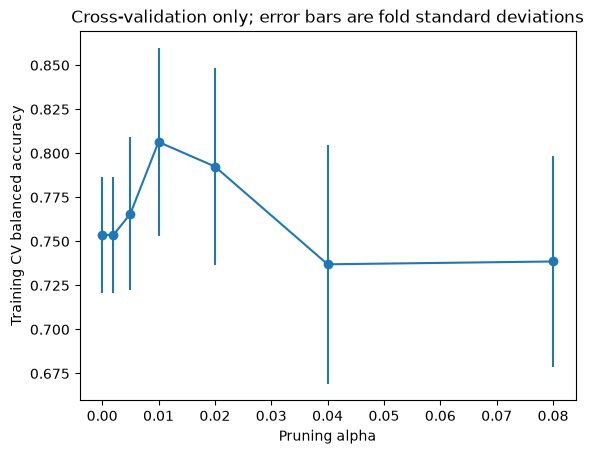

In [3]:
cv=pd.DataFrame(search.cv_results_)
plt.errorbar(cv['param_model__ccp_alpha'].astype(float),cv['mean_test_score'],yerr=cv['std_test_score'],marker='o')
plt.xlabel('Pruning alpha');plt.ylabel('Training CV balanced accuracy')
plt.title('Cross-validation only; error bars are fold standard deviations')
plt.show()


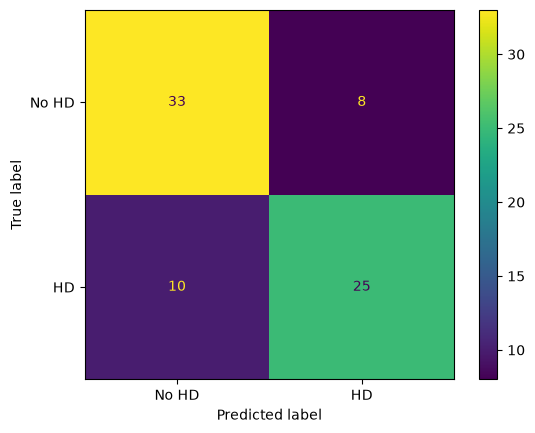

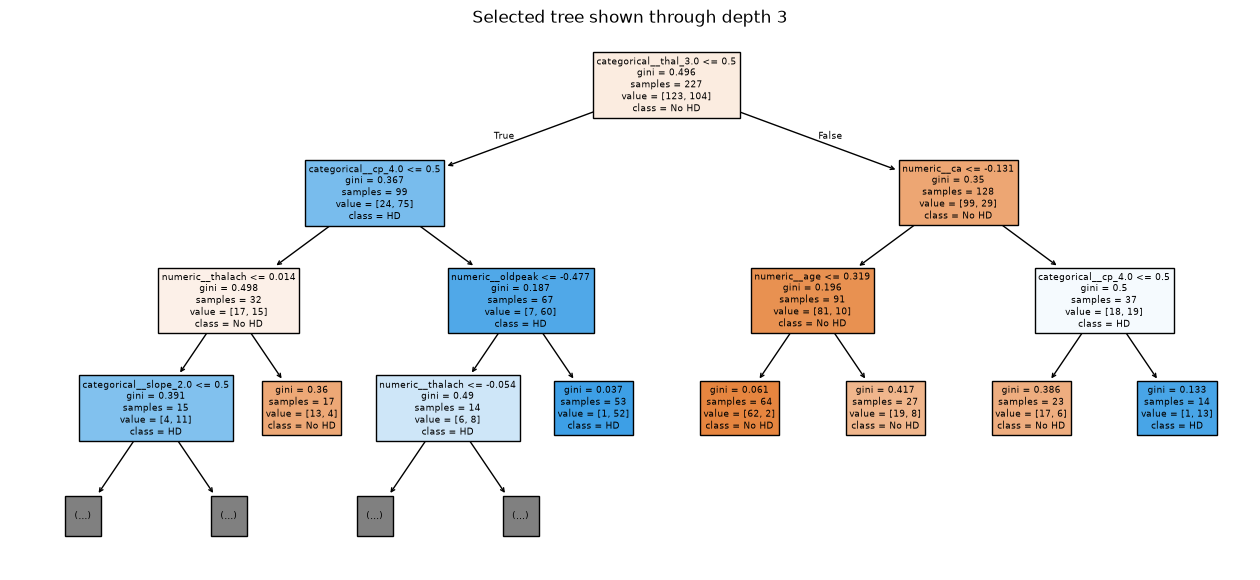

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import plot_tree
ConfusionMatrixDisplay.from_estimator(search.best_estimator_,X_test,y_test,display_labels=['No HD','HD'])
plt.show()
features=search.best_estimator_.named_steps['preprocess'].get_feature_names_out()
plt.figure(figsize=(16,7))
plot_tree(search.best_estimator_.named_steps['model'],feature_names=features,class_names=['No HD','HD'],filled=True,max_depth=3)
plt.title('Selected tree shown through depth 3');plt.show()


Class counts in the tree follow class order [0, 1]: no heart disease, then heart disease. Fold standard deviation is not a confidence interval. The small historical dataset and one holdout split limit conclusions. The holdout was inspected in the original learning notebook; this revised fixed protocol does not turn it into a genuinely unseen external validation dataset. Do not keep adjusting the grid to improve these test scores. See `reports/RESULTS.md` for measured results and limitations.

Numeric features are standardised inside the pipeline, so numeric thresholds in the tree diagram are in standardised units, not the original measurement units.
